In [1]:
import numpy as np
from itertools import chain

from response_stats.generators import PoissonSpikeGenerator
from response_stats.responses import ResponseConfig, make_response_data, ResponseDetector
from response_stats.responses.response_tests import WilcoxonTest, SurrogateTest

from response_stats.plot_utils import *

Baseline duration: 1 s
Mean, baseline: 0.7 Hz
Response duration, edge-corrected: 1.0000000000000009 s
Mean, response: 0.8210526315789474 Hz
5e-05


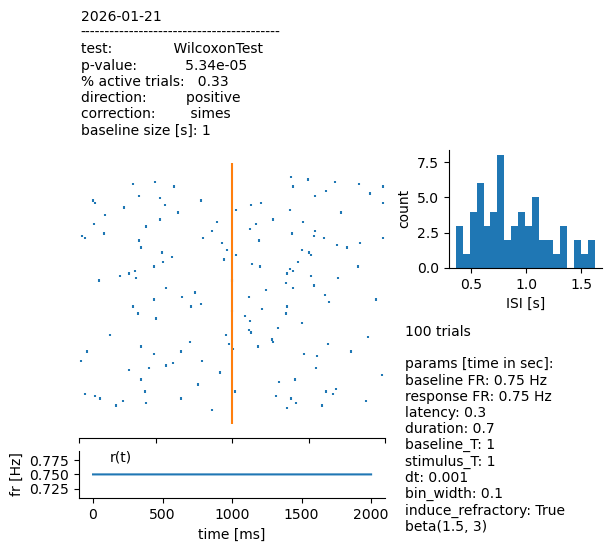

(<Figure size 600x400 with 4 Axes>,
 {'raster': <Axes: label='raster'>,
  'isi': <Axes: label='isi', xlabel='ISI [s]', ylabel='count'>,
  'text': <Axes: label='text'>,
  'r_t': <Axes: label='r_t', xlabel='time [ms]', ylabel='fr [Hz]'>})

In [42]:
fr = 0.75

baseline_fr = fr
response_fr = fr
latency = 0.3
duration = 0.7
dt = 0.001
baseline_T = 1
stimulus_T = 1
a = 1.5
b = 3

total_bins = int((baseline_T + stimulus_T) / dt)

induce_refractory_period = True

n_trials = 100

generator = PoissonSpikeGenerator(
    baseline_fr=baseline_fr,
    response_fr=response_fr,
    latency=latency,
    duration=duration,
    baseline_T=baseline_T,
    stimulus_T=stimulus_T,
    dt=dt,
    induce_refractory_period=induce_refractory_period,
    a = a,
    b = b,
)

trial_activity = generator.generate(n_trials)

cfg_response_dict = {
    "trial_activity": trial_activity,
    "baseline_T": baseline_T,
    "stimulus_T": stimulus_T,
    "stimulus_onset": baseline_T,
    "bin_width": 0.1,
    "dt": dt,
    "direction": "positive",
    "proportion_active": 1/3,
    "multiple_correction": "simes",
    "interleave_response_bins": True,
    "smooth_response_bins": False,
    "debug": True,
}

cfg_response = ResponseConfig(**cfg_response_dict)
data_response = make_response_data(cfg_response)

detector = ResponseDetector(data_response, WilcoxonTest)
print(round(detector.compute_min_pval(),5))
SpikeSummaryFigure(trial_activity, generator, detector, ).build()

In [59]:
res = {}
FRs = np.arange(0.5, 3, 0.25)
trial_list = [20, 30, 40, 50, 60, 70, 80, 85, 90, 100]

for fr in FRs:
    baseline_fr = fr
    response_fr = fr
    latency = 0.3
    duration = 0.7
    dt = 0.001
    baseline_T = 1
    stimulus_T = 1
    a = 1.5
    b = 3

    total_bins = int((baseline_T + stimulus_T) / dt)

    induce_refractory_period = True

    pval_collection = []

    for n_trials in trial_list:
        

        generator = PoissonSpikeGenerator(
            baseline_fr=baseline_fr,
            response_fr=response_fr,
            latency=latency,
            duration=duration,
            baseline_T=baseline_T,
            stimulus_T=stimulus_T,
            dt=dt,
            induce_refractory_period=induce_refractory_period,
            a = a,
            b = b,
        )

        trial_activity = generator.generate(n_trials)

        cfg_response_dict = {
            "trial_activity": trial_activity,
            "baseline_T": baseline_T,
            "stimulus_T": stimulus_T,
            "stimulus_onset": baseline_T,
            "bin_width": 0.1,
            "dt": dt,
            "direction": "positive",
            "proportion_active": 1/3,
            "multiple_correction": "simes",
            "interleave_response_bins": True,
            "smooth_response_bins": False,
            "debug": True,
        }

        cfg_response = ResponseConfig(**cfg_response_dict)
        data_response = make_response_data(cfg_response)

        detector = ResponseDetector(data_response, WilcoxonTest)
        print(round(detector.compute_min_pval(),5))
        pval_collection.append(detector.compute_min_pval())
    res[fr] = pval_collection

Baseline duration: 1 s
Mean, baseline: 0.65 Hz
Response duration, edge-corrected: 1.0000000000000009 s
Mean, response: 0.3157894736842105 Hz
6 active trials out of 20 trials (30.0%).
1.0
6 active trials out of 20 trials (30.0%).
Baseline duration: 1 s
Mean, baseline: 0.6666666666666666 Hz
Response duration, edge-corrected: 1.0000000000000009 s
Mean, response: 0.3157894736842105 Hz
9 active trials out of 30 trials (30.0%).
1.0
9 active trials out of 30 trials (30.0%).
Baseline duration: 1 s
Mean, baseline: 0.6 Hz
Response duration, edge-corrected: 1.0000000000000009 s
Mean, response: 0.32894736842105265 Hz
13 active trials out of 40 trials (32.5%).
1.0
13 active trials out of 40 trials (32.5%).
Baseline duration: 1 s
Mean, baseline: 0.64 Hz
Response duration, edge-corrected: 1.0000000000000009 s
Mean, response: 0.3263157894736842 Hz
16 active trials out of 50 trials (32.0%).
1.0
16 active trials out of 50 trials (32.0%).
Baseline duration: 1 s
Mean, baseline: 0.6 Hz
Response duration, e

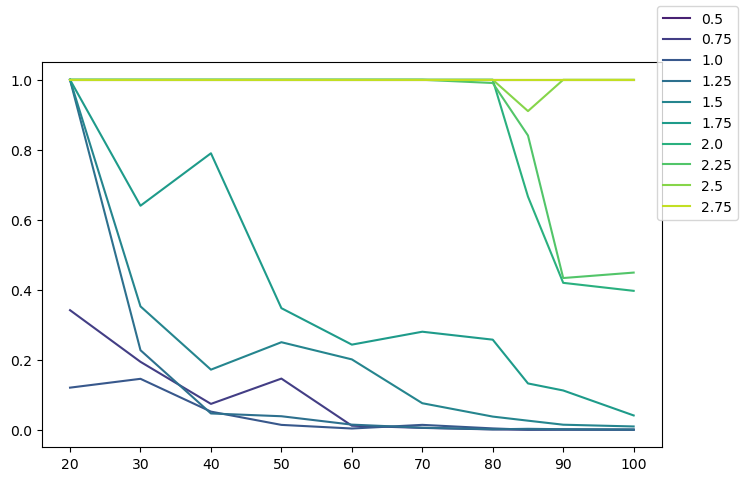

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

palette = sns.color_palette("viridis", n_colors=len(res))

fig, ax = plt.subplots(1, 1, figsize=(8, 5))

for color, fr in zip(palette, res.keys()):
    y = res[fr]
    ax.plot(trial_list, y, color=color, label=fr)
fig.legend()
plt.show()

In [ ]:
baseline_fr = 0.5

e = 3
gain_high = 50
b = (gain_high - e) 
y = 3
x = baseline_fr

gain = (1/y)**x * b  + e
response_fr = round(baseline_fr * gain,3)

latency = 0.3
duration = 0.5
dt = 0.001
baseline_T = 1
stimulus_T = 1
a = 1.
b = 1.75

total_bins = int((baseline_T + stimulus_T) / dt)

induce_refractory_period = True

n_trials = 10

generator = PoissonSpikeGenerator(
    baseline_fr=baseline_fr,
    response_fr=response_fr,
    latency=latency,
    duration=duration,
    baseline_T=baseline_T,
    stimulus_T=stimulus_T,
    dt=dt,
    induce_refractory_period=induce_refractory_period,
    a = a,
    b = b,
)

trial_activity = generator.generate(n_trials)

cfg_response_dict = {
    "trial_activity": trial_activity,
    "baseline_T": baseline_T,
    "stimulus_T": stimulus_T,
    "stimulus_onset": baseline_T,
    "bin_width": 0.1,
    "dt": dt,
    "direction": "positive",
    "proportion_active": 1/3,
    "multiple_correction": "simes",
    "interleave_response_bins": True,
    "smooth_response_bins": False,
    "debug": True,
}

cfg_response = ResponseConfig(**cfg_response_dict)
data_response = make_response_data(cfg_response)


detector = ResponseDetector(data_response, WilcoxonTest)

SpikeSummaryFigure(trial_activity, generator, detector, ).build()